In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Acer\.cache\kagglehub\datasets\asinow\video_games_sales.csv")
print(df.head())

   rank                      name platform    year         genre publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   na_sales  eu_sales  jp_sales  other_sales  global_sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


In [4]:
df.isnull().sum()

rank              0
name              0
platform          0
year            271
genre             0
publisher        58
na_sales          0
eu_sales          0
jp_sales          0
other_sales       0
global_sales      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          16598 non-null  int64  
 1   name          16598 non-null  object 
 2   platform      16598 non-null  object 
 3   year          16327 non-null  float64
 4   genre         16598 non-null  object 
 5   publisher     16540 non-null  object 
 6   na_sales      16598 non-null  float64
 7   eu_sales      16598 non-null  float64
 8   jp_sales      16598 non-null  float64
 9   other_sales   16598 non-null  float64
 10  global_sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
df.describe()

,rank,year,na_sales,eu_sales,jp_sales,other_sales,global_sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [8]:
df.dropna(inplace=True)
df.isnull().sum()

rank            0
name            0
platform        0
year            0
genre           0
publisher       0
na_sales        0
eu_sales        0
jp_sales        0
other_sales     0
global_sales    0
dtype: int64

                        name  global_sales
0                 Wii Sports         82.74
1          Super Mario Bros.         40.24
2             Mario Kart Wii         35.82
3          Wii Sports Resort         33.00
4   Pokemon Red/Pokemon Blue         31.37
5                     Tetris         30.26
6      New Super Mario Bros.         30.01
7                   Wii Play         29.02
8  New Super Mario Bros. Wii         28.62
9                  Duck Hunt         28.31


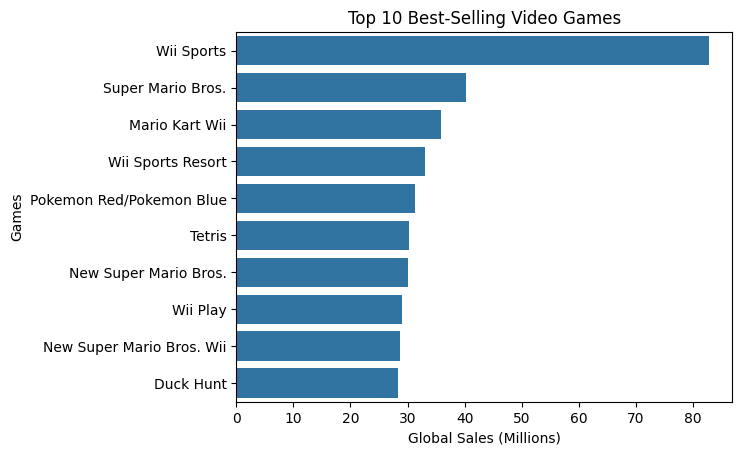

In [13]:
top_games = df[['name', 'global_sales']].sort_values(by='global_sales', ascending=False).head(10)
print(top_games)

import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=top_games['global_sales'], y=top_games['name'])
plt.title('Top 10 Best-Selling Video Games')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Games')
plt.show()

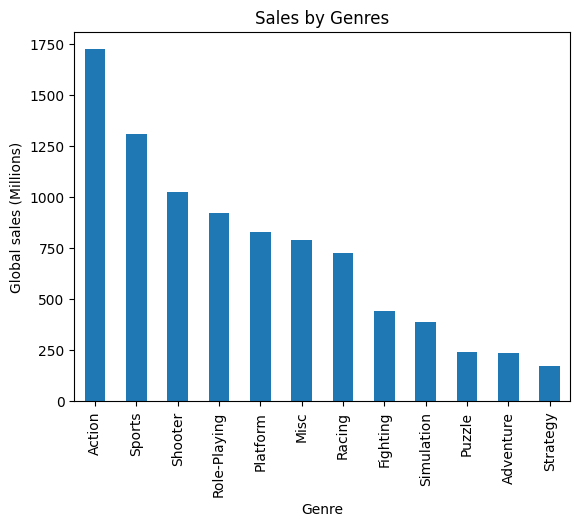

In [16]:
genre_sales = df.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

genre_sales.plot(kind='bar')
plt.title('Sales by Genres')
plt.xlabel('Genre')
plt.ylabel('Global sales (Millions)')
plt.show()

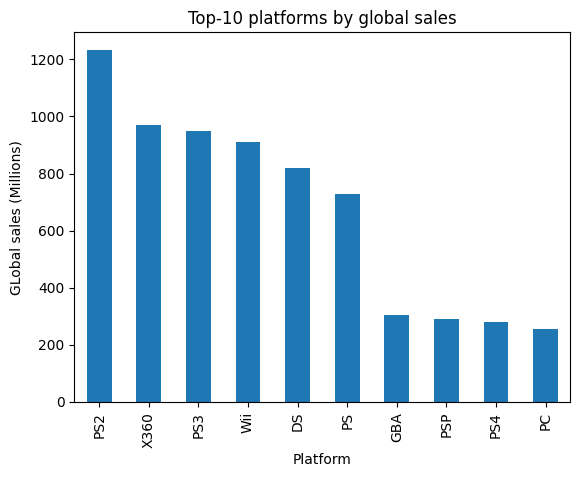

In [17]:
platform_sales = df.groupby('platform')['global_sales'].sum().sort_values(ascending=False).head(10)

platform_sales.plot(kind='bar')
plt.title('Top-10 platforms by global sales')
plt.xlabel('Platform')
plt.ylabel('GLobal sales (Millions)')
plt.show()

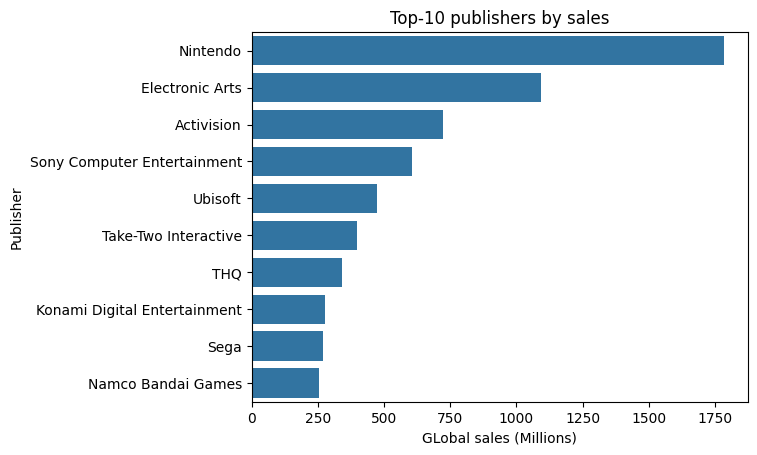

In [29]:
top_publishers = df.groupby('publisher')['global_sales'].sum().nlargest(10).reset_index()

sns.barplot(data=top_publishers, x='global_sales', y='publisher')
plt.title('Top-10 publishers by sales')
plt.xlabel('GLobal sales (Millions)')
plt.ylabel('Publisher')
plt.show()

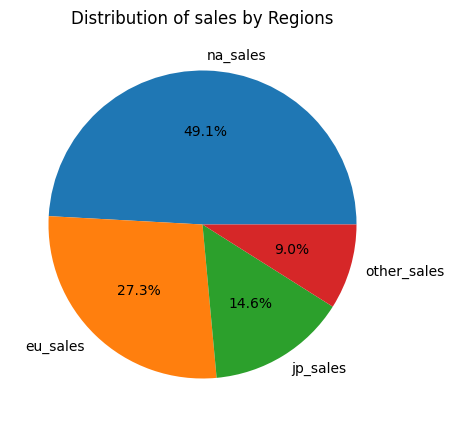

In [22]:
region_sales = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%' , figsize=(5,5))
plt.title('Distribution of sales by Regions')
plt.show()

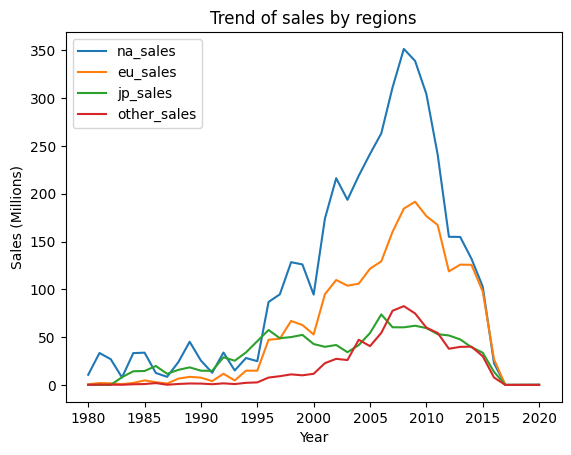

In [23]:
region_trends = df.groupby('year')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

region_trends.plot()
plt.title('Trend of sales by regions')
plt.xlabel('Year')
plt.ylabel('Sales (Millions)')
plt.show()

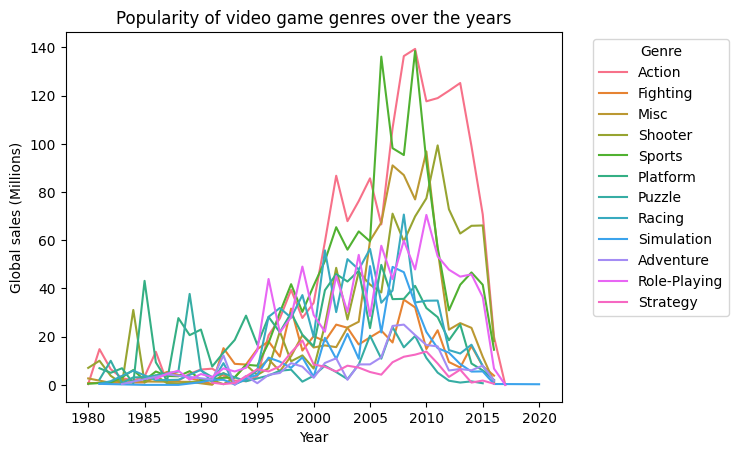

In [37]:
genre_trends = df.groupby(['year', 'genre'])['global_sales'].sum().reset_index()

sns.lineplot(data=genre_trends, x='year', y='global_sales', hue='genre')
plt.title('Popularity of video game genres over the years')
plt.xlabel('Year')
plt.ylabel('Global sales (Millions)')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

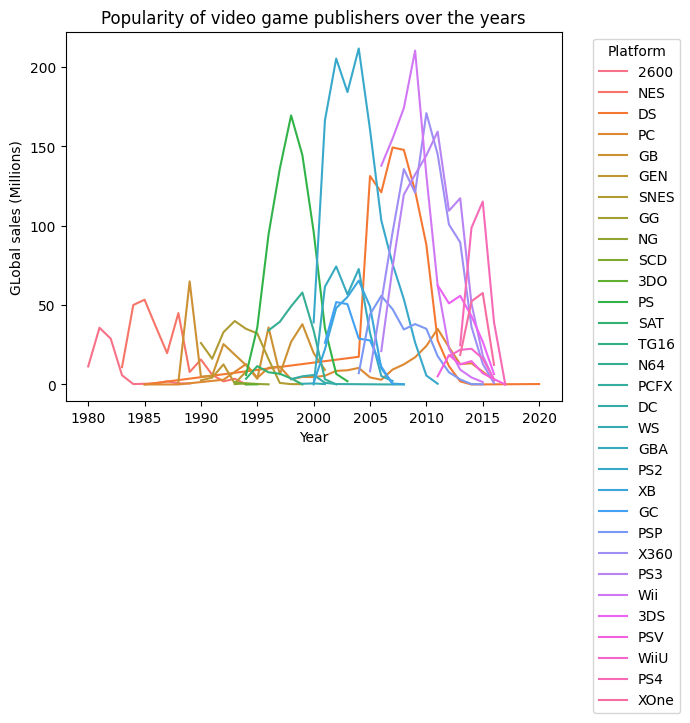

In [38]:
platform_trends = df.groupby(['year', 'platform'])['global_sales'].sum().reset_index()

sns.lineplot(data=platform_trends, x='year', y='global_sales', hue='platform')
plt.title('Popularity of video game publishers over the years')
plt.xlabel('Year')
plt.ylabel('GLobal sales (Millions)')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

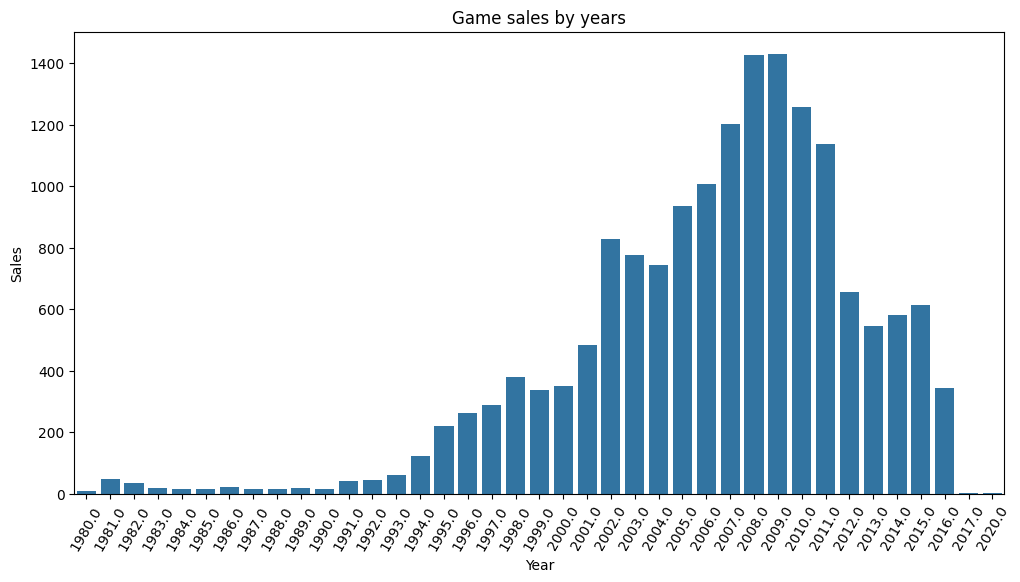

In [44]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='year')
plt.xticks(rotation=60)
plt.title('Game sales by years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

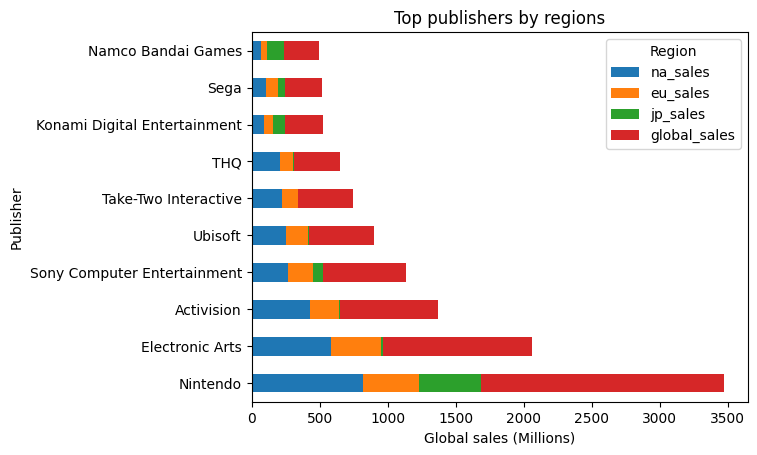

In [50]:
top_publishers = df.groupby('publisher')[['na_sales', 'eu_sales', 'jp_sales', 'global_sales']].sum().nlargest(10, 'global_sales')

top_publishers.plot(kind='barh', stacked=True)
plt.title('Top publishers by regions')
plt.xlabel('Global sales (Millions)')
plt.ylabel('Publisher')
plt.legend(title='Region')
plt.show()
